In [1]:
import pandas as pd

file_path = '2023년도+폐기물+재활용실적+및+업체현황.xlsx'
# 멀티헤더 + 4번째 줄부터 실제 데이터 시작
df_raw = pd.read_excel(
    file_path,
    sheet_name='재활용실적(12)',
    skiprows=3,
    header=[0, 1],
    engine='openpyxl'
)

# 열 납작하게 만들기 (숫자 포함 안전 처리)
df_raw.columns = ['_'.join([str(c) for c in col if c]).strip() for col in df_raw.columns]

# 정확히 '폐기물종류' 포함된 6개 열만 수동 선택
df_raw = df_raw.iloc[:, 0:6]
df_raw.head()

,Unnamed: 0_level_0_Unnamed: 0_level_1,Unnamed: 1_level_0_계,Unnamed: 2_level_0_1801,톤/년_4421782.096999999,구성비(%)_100,톤/년_3343258.3601099993
0,NaN,폐합성고분자화합물,101.0,30915.543,0.699165,46297.701
1,NaN,오니류,66.0,269832.295,6.102343,95578.934
2,NaN,폐농약,1.0,123.090,0.002784,123.090
3,NaN,폐산,219.0,1131287.830,25.584432,1208512.836
4,NaN,폐알칼리,63.0,52409.433,1.185256,86860.450


In [2]:
df_raw.columns = [
    '폐기물종류',
    '가동업체수',
    '재활용량(톤)',
    '재활용 구성비(%)',
    '판매량(톤)',
    '판매 구성비(%)'
]
df_raw.head()

,폐기물종류,가동업체수,재활용량(톤),재활용 구성비(%),판매량(톤),판매 구성비(%)
0,NaN,폐합성고분자화합물,101.0,30915.543,0.699165,46297.701
1,NaN,오니류,66.0,269832.295,6.102343,95578.934
2,NaN,폐농약,1.0,123.090,0.002784,123.090
3,NaN,폐산,219.0,1131287.830,25.584432,1208512.836
4,NaN,폐알칼리,63.0,52409.433,1.185256,86860.450


In [3]:
def strip_and_count(x):
    if isinstance(x, str):
        original = x
        stripped = x.strip()
        return stripped, original != stripped
    return x, False
changed_count = 0
for col in df_raw.select_dtypes(include='object').columns:
    stripped_results = df_raw[col].apply(strip_and_count)
    df_raw[col] = stripped_results.apply(lambda x: x[0])
    changed_count += stripped_results.map(lambda x: x[1]).sum()


In [4]:
print("전처리 전 확인 :")
print(df_raw.dtypes)
df_raw.head()

전처리 전 확인 :
폐기물종류         float64
가동업체수          object
재활용량(톤)       float64
재활용 구성비(%)    float64
판매량(톤)        float64
판매 구성비(%)     float64
dtype: object


,폐기물종류,가동업체수,재활용량(톤),재활용 구성비(%),판매량(톤),판매 구성비(%)
0,NaN,폐합성고분자화합물,101.0,30915.543,0.699165,46297.701
1,NaN,오니류,66.0,269832.295,6.102343,95578.934
2,NaN,폐농약,1.0,123.090,0.002784,123.090
3,NaN,폐산,219.0,1131287.830,25.584432,1208512.836
4,NaN,폐알칼리,63.0,52409.433,1.185256,86860.450


In [5]:

df_raw['재활용률(%)'] = (df_raw['판매량(톤)'] / df_raw['재활용량(톤)']) * 100
print(df_raw[['폐기물종류', '재활용량(톤)', '판매량(톤)', '재활용률(%)']].head(10))

   폐기물종류  재활용량(톤)     판매량(톤)    재활용률(%)
0    NaN    101.0   0.699165   0.692242
1    NaN     66.0   6.102343   9.245974
2    NaN      1.0   0.002784   0.278372
3    NaN    219.0  25.584432  11.682389
4    NaN     63.0   1.185256   1.881359
5    NaN     25.0   4.225861  16.903444
6    NaN     36.0  10.939418  30.387272
7    NaN      1.0   0.000000   0.000000
8    NaN      0.0   0.000000        NaN
9    NaN      3.0   0.236913   7.897103


In [6]:
df_filtered = df_raw[df_raw['재활용률(%)'].notna() & (df_raw['재활용률(%)'] > 0)]
print(f"유효한 데이터 수: {len(df_filtered)}")


유효한 데이터 수: 18


C:\Users\lyjin\AppData\Local\Temp\ipykernel_5288\3820454819.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x='폐기물종류', y='재활용률(%)', palette='Blues')
C:\Users\lyjin\AppData\Local\Temp\ipykernel_5288\3820454819.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(data=df_top10, x='폐기물종류', y='재활용률(%)', palette='Blues')


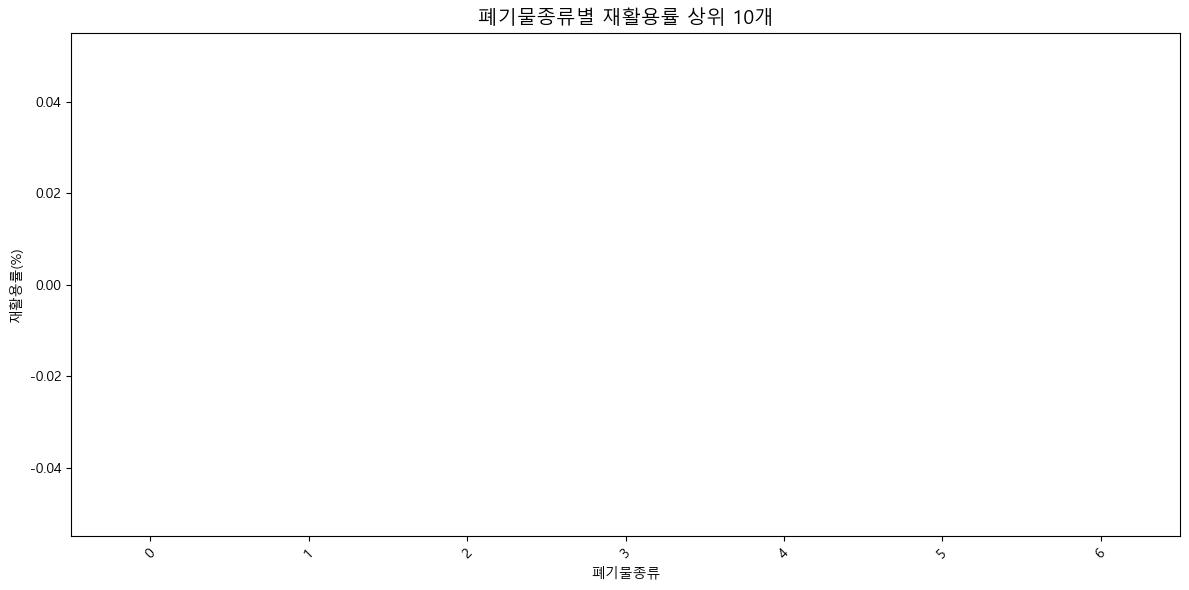

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상위 10개만 추출
df_top10 = df_filtered.sort_values(by='재활용률(%)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top10, x='폐기물종류', y='재활용률(%)', palette='Blues')
plt.title('폐기물종류별 재활용률 상위 10개', fontsize=14)
plt.xlabel('폐기물종류')
plt.ylabel('재활용률(%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
